In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [2]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
BASE_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'

train_df = pd.read_csv(f'{BASE_DIR}/train.csv')
test_df = pd.read_csv(f'{BASE_DIR}/test.csv')

In [4]:
train_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [5]:
seed=42
torch.manual_seed(seed)

In [6]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)
assert device.type == "cuda", "No GPU! Set Session options -> Accelerator -> GPU T4 x2 (or P100)"

Device: cuda


In [7]:
from sklearn.model_selection import train_test_split

train_df_split, temp_df = train_test_split(train_df,test_size=0.3,
                                           random_state=seed,stratify=train_df['diagnosis']
)

val_df, test_df_split = train_test_split(temp_df,test_size=0.5,
                                         random_state=seed, stratify=temp_df['diagnosis']
)

print("Train:", train_df_split.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df_split.shape)

Train: (2563, 2)
Val:   (549, 2)
Test:  (550, 2)


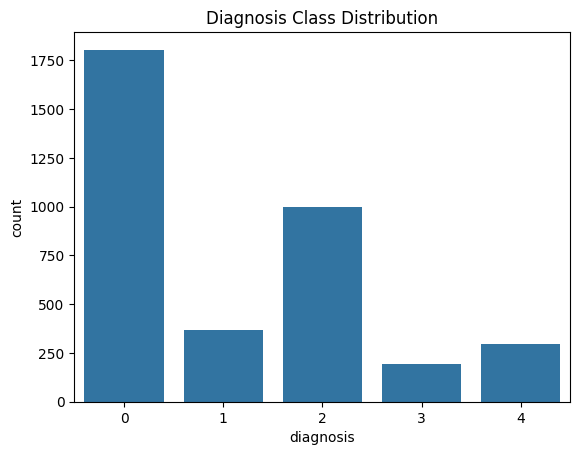

In [8]:
sns.countplot(x='diagnosis', data=train_df)
plt.title('Diagnosis Class Distribution')
plt.show()

In [9]:
train_df_split['file_path'] = train_df_split['id_code'].apply(lambda x: f'{BASE_DIR}/train_images/{x}.png')
val_df['file_path'] = val_df['id_code'].apply(lambda x: f'{BASE_DIR}/train_images/{x}.png')
test_df_split['file_path'] = test_df_split['id_code'].apply(lambda x: f'{BASE_DIR}/train_images/{x}.png')

In [10]:
import os, glob

# --- Find 2015 labels (columns: image, level) ---
csv_2015 = [f for f in glob.glob('/kaggle/input/datasets/*/*/**/*.csv', recursive=True)
            if 'level' in pd.read_csv(f, nrows=1).columns][0]
df15 = pd.read_csv(csv_2015)
print("2015 labels:", csv_2015, "| rows:", len(df15))

# --- Find the folder holding the 2015 images ---
sample = df15['image'].iloc[0]
img_file = glob.glob(f'/kaggle/input/datasets/*/*/**/{sample}.*', recursive=True)[0]
IMG_DIR_15, EXT_15 = os.path.dirname(img_file), os.path.splitext(img_file)[1]
print("2015 images:", IMG_DIR_15, "| extension:", EXT_15)

df15 = df15.rename(columns={'level': 'diagnosis'})
df15['file_path'] = df15['image'].apply(lambda x: f'{IMG_DIR_15}/{x}{EXT_15}')
df15 = df15[df15['file_path'].apply(os.path.exists)]

# --- Keep all diseased images + 8000 healthy ones ---
df15 = pd.concat([df15[df15['diagnosis'] > 0],
                  df15[df15['diagnosis'] == 0].sample(8000, random_state=seed)])
print("2015 images used:", len(df15), df15['diagnosis'].value_counts().sort_index().to_dict())

# --- Train on APTOS train + 2015; validation and test stay APTOS only ---
train_df_split = pd.concat([train_df_split[['id_code', 'diagnosis', 'file_path']],
                            df15[['diagnosis', 'file_path']]], ignore_index=True)
print("Combined training set:", len(train_df_split))

2015 labels: /kaggle/input/datasets/tanlikesmath/diabetic-retinopathy-resized/trainLabels.csv | rows: 35126
2015 images: /kaggle/input/datasets/tanlikesmath/diabetic-retinopathy-resized/resized_train/resized_train | extension: .jpeg
2015 images used: 17316 {0: 8000, 1: 2443, 2: 5292, 3: 873, 4: 708}
Combined training set: 19879


In [11]:
test_df['file_path'] = test_df['id_code'].apply(lambda x: f'{BASE_DIR}/test_images/{x}.png')


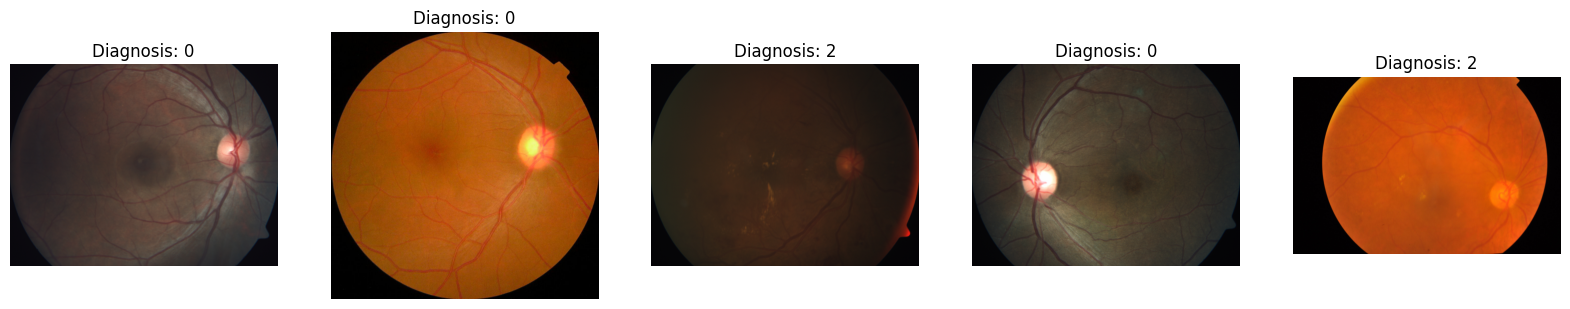

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    img = plt.imread(train_df_split['file_path'].iloc[i])
    ax.imshow(img)
    ax.set_title(f"Diagnosis: {train_df_split['diagnosis'].iloc[i]}")
    ax.axis('off')
plt.show()

In [13]:
from torchvision import transforms

IMG_SIZE = 320

# ben_graham() already crops and resizes to IMG_SIZE, so no Resize here
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [14]:
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

def crop_circle(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    ys, xs = np.where(mask)
    return img[ys.min():ys.max()+1, xs.min():xs.max()+1]

def ben_graham(path, size=IMG_SIZE, sigma=10):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(crop_circle(img), (size, size))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma), -4, 128)
    return Image.fromarray(img)

class CustomDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = self.transform(ben_graham(row['file_path']))
        label = torch.tensor(row['diagnosis'], dtype=torch.float32)   # float for regression
        return image, label


In [15]:
class KaggleTestDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        return self.transform(ben_graham(self.df.iloc[index]['file_path']))

In [16]:
train_dataset = CustomDataset(train_df_split, transform=train_transform)
val_dataset = CustomDataset(val_df, transform=val_transform)
test_dataset = CustomDataset(test_df_split, transform=val_transform)

In [17]:
kaggle_test_dataset = KaggleTestDataset(test_df, transform=val_transform)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, num_workers=4,pin_memory=True,shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4,pin_memory=True)

In [19]:
test_loader_kaggle = DataLoader(kaggle_test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [20]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape, labels.dtype)

torch.Size([32, 3, 320, 320]) torch.Size([32]) torch.float32


In [21]:
from torchvision import models
import torch.nn as nn

effinet = models.efficientnet_b3(weights='IMAGENET1K_V1')    
effinet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(effinet.classifier[1].in_features, 1),        # regression output
)
effinet = effinet.to(device)
print("EfficientNet-B3 ready")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 140MB/s]


EfficientNet-B3 ready


In [22]:
print(effinet)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [23]:
print(effinet.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1536, out_features=1, bias=True)
)


In [24]:
trainable = sum(p.numel() for p in effinet.parameters() if p.requires_grad)
total = sum(p.numel() for p in effinet.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")


Trainable: 10,697,769 / Total: 10,697,769


In [25]:
optimizer = torch.optim.Adam(effinet.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.MSELoss()
num_epochs = 8
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.amp.GradScaler("cuda")

In [26]:
from sklearn.metrics import cohen_kappa_score
import time

history = {'train_loss': [], 'val_loss': [], 'val_kappa': []}
best_val_kappa = -1

for epoch in range(num_epochs):
    start_time = time.time()

    # ---------------- TRAINING ----------------
    effinet.train()
    running_loss, total = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast("cuda"):
            outputs = effinet(images).squeeze(1)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
    train_loss = running_loss / total

    # ---------------- VALIDATION ----------------
    effinet.eval()
    val_running_loss, val_total = 0.0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.autocast("cuda"):
                outputs = effinet(images).squeeze(1)
                loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            val_total += labels.size(0)
            all_preds.extend(outputs.float().round().clamp(0, 4).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_kappa'].append(val_kappa)

    print(f"Epoch {epoch+1}/{num_epochs} ({time.time() - start_time:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Kappa: {val_kappa:.4f}")

    if val_kappa > best_val_kappa:
        best_val_kappa = val_kappa
        torch.save(effinet.state_dict(), 'best_model_effi.pth')
        print(f"  → New best model saved (kappa: {val_kappa:.4f})")

Epoch 1/8 (562.3s) | Train Loss: 0.8454 | Val Loss: 0.3792 | Val Kappa: 0.8524
  → New best model saved (kappa: 0.8524)
Epoch 2/8 (481.5s) | Train Loss: 0.6537 | Val Loss: 0.3879 | Val Kappa: 0.8361
Epoch 3/8 (473.7s) | Train Loss: 0.5845 | Val Loss: 0.3465 | Val Kappa: 0.8674
  → New best model saved (kappa: 0.8674)
Epoch 4/8 (477.8s) | Train Loss: 0.5415 | Val Loss: 0.3170 | Val Kappa: 0.8896
  → New best model saved (kappa: 0.8896)
Epoch 5/8 (475.3s) | Train Loss: 0.5115 | Val Loss: 0.3190 | Val Kappa: 0.8754
Epoch 6/8 (480.0s) | Train Loss: 0.4816 | Val Loss: 0.3145 | Val Kappa: 0.8794
Epoch 7/8 (478.0s) | Train Loss: 0.4659 | Val Loss: 0.3061 | Val Kappa: 0.8848
Epoch 8/8 (477.8s) | Train Loss: 0.4561 | Val Loss: 0.3173 | Val Kappa: 0.8744


In [27]:
import numpy as np
from scipy.optimize import minimize

effinet.load_state_dict(torch.load('best_model_effi.pth'))
effinet.eval()

def get_preds(loader, tta=True):
    out = []
    with torch.no_grad():
        for batch in loader:
            images = batch[0] if isinstance(batch, (list, tuple)) else batch
            images = images.to(device)
            p = effinet(images).squeeze(1)
            if tta:                                        # average with flipped image
                p = (p + effinet(torch.flip(images, dims=[3])).squeeze(1)) / 2
            out.extend(p.float().cpu().numpy())
    return np.array(out)

val_raw = get_preds(val_loader)
val_true = val_df['diagnosis'].values

def neg_kappa(t):
    return -cohen_kappa_score(val_true, np.digitize(val_raw, np.sort(t)), weights='quadratic')

best_t = np.sort(minimize(neg_kappa, [0.5, 1.5, 2.5, 3.5], method='Nelder-Mead').x)
print("Val kappa (rounding):", cohen_kappa_score(val_true, np.clip(np.round(val_raw), 0, 4), weights='quadratic'))
print("Val kappa (tuned):   ", -neg_kappa(best_t))
print("BEST_T =", list(best_t))

# Save thresholds so they appear in the Output tab
np.save('/kaggle/working/best_thresholds.npy', best_t)
print("Thresholds saved to /kaggle/working/best_thresholds.npy")

Val kappa (rounding): 0.8913846870214489
Val kappa (tuned):    0.8944495677421247
BEST_T = [np.float64(0.5243591308593749), np.float64(1.4776794433593747), np.float64(2.46282958984375), np.float64(3.4818420410156254)]
Thresholds saved to /kaggle/working/best_thresholds.npy


In [28]:
from sklearn.metrics import accuracy_score, classification_report

test_raw = get_preds(test_loader)
test_preds = np.digitize(test_raw, best_t)
test_labels = test_df_split['diagnosis'].values

print(f"Final Test Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
print(f"Final Test Kappa:    {cohen_kappa_score(test_labels, test_preds, weights='quadratic'):.4f}")
print(classification_report(test_labels, test_preds,
      target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']))

Final Test Accuracy: 0.8000
Final Test Kappa:    0.9151
               precision    recall  f1-score   support

        No DR       0.99      0.99      0.99       271
         Mild       0.77      0.43      0.55        56
     Moderate       0.71      0.80      0.75       150
       Severe       0.25      0.52      0.34        29
Proliferative       0.67      0.27      0.39        44

     accuracy                           0.80       550
    macro avg       0.68      0.60      0.60       550
 weighted avg       0.83      0.80      0.80       550

